In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [4]:
file = r"files/one_dollar_spin_and_go.csv"
df = pd.read_csv(file)

In [5]:
df.head()

,buyin,tourn_id,table,hand_id,date,time,table_size,level,playing,seat,...,pot_turn,pot_river,ante,blinds,bet_pre,bet_flop,bet_turn,bet_river,result,balance
0,$0.92+$0.08,2929450288,1,215051507105,2020-06-07,18:15:09,3,1,3,1,...,30,30,0,0,0,0,0,0,gave up,0
1,$0.92+$0.08,2929450288,1,215051507105,2020-06-07,18:15:09,3,1,3,2,...,30,30,0,10,10,0,0,0,gave up,-10
2,$0.92+$0.08,2929450288,1,215051507105,2020-06-07,18:15:09,3,1,3,3,...,30,30,0,20,20,0,0,0,took chips,10
3,$0.92+$0.08,2929450288,1,215051520234,2020-06-07,18:15:23,3,1,3,1,...,180,180,0,20,60,60,0,0,took chips,60
4,$0.92+$0.08,2929450288,1,215051520234,2020-06-07,18:15:23,3,1,3,2,...,180,180,0,0,0,0,0,0,gave up,0


In [6]:
df.size

3591525

In [7]:
print("Dataset Info:")
print(df.info())
print("\n" + "="*50 + "\n")
print("Dataset Shape:", df.shape)
print("\nBasic Statistics:")
print(df.describe())

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 102615 entries, 0 to 102614
Data columns (total 35 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   buyin         102615 non-null  str  
 1   tourn_id      102615 non-null  int64
 2   table         102615 non-null  int64
 3   hand_id       102615 non-null  int64
 4   date          102615 non-null  str  
 5   time          102615 non-null  str  
 6   table_size    102615 non-null  int64
 7   level         102615 non-null  int64
 8   playing       102615 non-null  int64
 9   seat          102615 non-null  int64
 10  name          102615 non-null  str  
 11  stack         102615 non-null  int64
 12  position      102615 non-null  str  
 13  action_pre    102615 non-null  str  
 14  action_flop   102615 non-null  str  
 15  action_turn   102615 non-null  str  
 16  action_river  102615 non-null  str  
 17  all_in        102615 non-null  bool 
 18  cards         102615 non-null  str  
 19 

In [37]:
df['won_flag'] = df['result'].isin(['won', 'took chips']).astype(int)
df['lost_flag'] = df['result'].isin(['lost', 'gave up']).astype(int)

df['total_bet'] = df[['bet_pre', 'bet_flop', 'bet_turn', 'bet_river']].fillna(0).sum(axis=1)
df['final_pot'] = df['pot_river'].where(df['pot_river'] > 0,
                    df['pot_turn'].where(df['pot_turn'] > 0,
                        df['pot_flop'].where(df['pot_flop'] > 0, df['pot_pre'])))
df['bet_to_pot_ratio'] = np.where(df['final_pot'] > 0, df['total_bet'] / df['final_pot'], 0)
df['roi'] = np.where(df['total_bet'] > 0, df['balance'] / df['total_bet'], 0)
df['street_bets'] = df[['bet_pre', 'bet_flop', 'bet_turn', 'bet_river']].gt(0).sum(axis=1)
df['raise_count'] = df[['action_pre', 'action_flop', 'action_turn', 'action_river']].fillna('').apply(lambda x: x.str.contains('raise', case=False, na=False)).sum(axis=1)
df['has_raise'] = (df['raise_count'] > 0).astype(int)

C:\Users\garrido-lestachebeli\AppData\Local\Temp\ipykernel_32072\3735167076.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_df.index, y=missing_df['Missing_Count'], palette='husl')


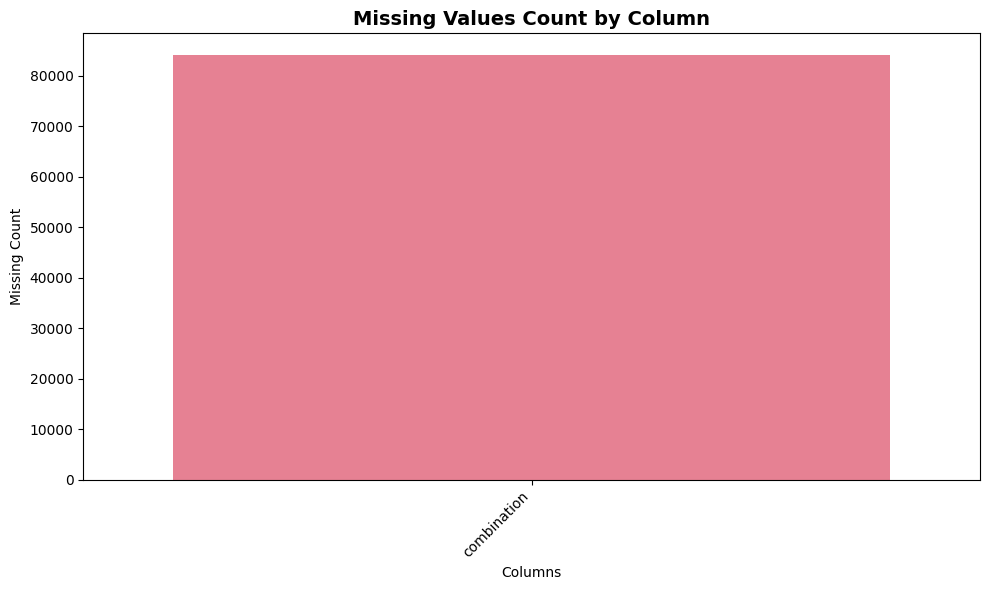

In [7]:
plt.figure(figsize=(10, 6))
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({'Missing_Count': missing_data, 'Percentage': missing_percent})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_df) > 0:
    sns.barplot(x=missing_df.index, y=missing_df['Missing_Count'], palette='husl')
    plt.title('Missing Values Count by Column', fontsize=14, fontweight='bold')
    plt.xlabel('Columns')
    plt.ylabel('Missing Count')
    plt.xticks(rotation=45, ha='right')
else:
    print("No missing values found in the dataset!")
    plt.close()

plt.tight_layout()
plt.show()


In [8]:
from collections import Counter
from itertools import combinations

rank_map = {
    '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8, '9': 9,
    'T': 10, 'J': 11, 'Q': 12, 'K': 13, 'A': 14
}

category_keywords = {
    'straight flush': 'straight flush',
    'four of a kind': 'four of a kind',
    'full house': 'full house',
    'flush': 'flush',
    'straight': 'straight',
    'three of a kind': 'three of a kind',
    'two pair': 'two pair',
    'pair': 'pair',
    'high card': 'high card'
}


def parse_cards(value):
    if pd.isna(value):
        return []
    text = str(value).strip()
    if text in ('', '0', '--', 'nan', 'None'):
        return []
    return [card for card in text.split() if card not in ('0', '--')]


def card_rank(card):
    if len(card) < 2:
        return None
    return rank_map.get(card[0].upper())


def card_suit(card):
    if len(card) < 2:
        return None
    return card[1].lower()


def is_straight(ranks):
    ranks = sorted(set(ranks))
    if len(ranks) < 5:
        return False
    if 14 in ranks:
        ranks = [1] + ranks
    for i in range(len(ranks) - 4):
        window = ranks[i:i + 5]
        if window == list(range(window[0], window[0] + 5)):
            return True
    return False


def best_combination_from_cards(cards):
    card_ranks = [card_rank(c) for c in cards if card_rank(c) is not None]
    card_suits = [card_suit(c) for c in cards if card_suit(c) is not None]
    counts = Counter(card_ranks)
    counts_values = sorted(counts.values(), reverse=True)

    if len(card_ranks) == 0:
        return 'unknown'
    if len(card_ranks) < 5:
        if 3 in counts_values:
            return 'three of a kind'
        if counts_values.count(2) >= 2:
            return 'two pair'
        if 2 in counts_values:
            return 'pair'
        return 'high card'

    suits = Counter(card_suits)
    flush_suit = next((s for s, cnt in suits.items() if cnt >= 5), None)
    flush_cards = [card for card in cards if card_suit(card) == flush_suit] if flush_suit else []
    flush_ranks = [card_rank(card) for card in flush_cards]

    straight = is_straight(card_ranks)
    straight_flush = flush_suit is not None and is_straight(flush_ranks)

    if straight_flush:
        return 'straight flush'
    if 4 in counts_values:
        return 'four of a kind'
    if 3 in counts_values and 2 in counts_values:
        return 'full house'
    if flush_suit is not None:
        return 'flush'
    if straight:
        return 'straight'
    if 3 in counts_values:
        return 'three of a kind'
    if counts_values.count(2) >= 2:
        return 'two pair'
    if 2 in counts_values:
        return 'pair'
    return 'high card'


def normalize_combination(text):
    lower_text = str(text).lower()
    for key, label in category_keywords.items():
        if key in lower_text:
            return label
    return ''

# Normalize existing text values first.
df['combination'] = df['combination'].astype(str).fillna('').apply(normalize_combination)

# Rebuild missing or unrecognized rows from card data.
missing_mask = df['combination'].isin(['', 'nan'])
card_cols = ['cards', 'board_flop', 'board_turn', 'board_river']

for idx in df[missing_mask].index:
    cards = []
    for col in card_cols:
        cards.extend(parse_cards(df.at[idx, col]))
    df.at[idx, 'combination'] = best_combination_from_cards(cards)

# Final fallback value.
df['combination'] = df['combination'].replace({'': 'unknown', 'nan': 'unknown'})

Numeric columns found: ['tourn_id', 'table', 'hand_id', 'table_size', 'level', 'playing', 'seat', 'stack', 'pot_pre', 'pot_flop', 'pot_turn', 'pot_river', 'ante', 'blinds', 'bet_pre', 'bet_flop', 'bet_turn', 'bet_river', 'balance', 'won_flag', 'lost_flag', 'total_bet', 'final_pot', 'bet_to_pot_ratio', 'roi', 'street_bets', 'raise_count', 'has_raise']


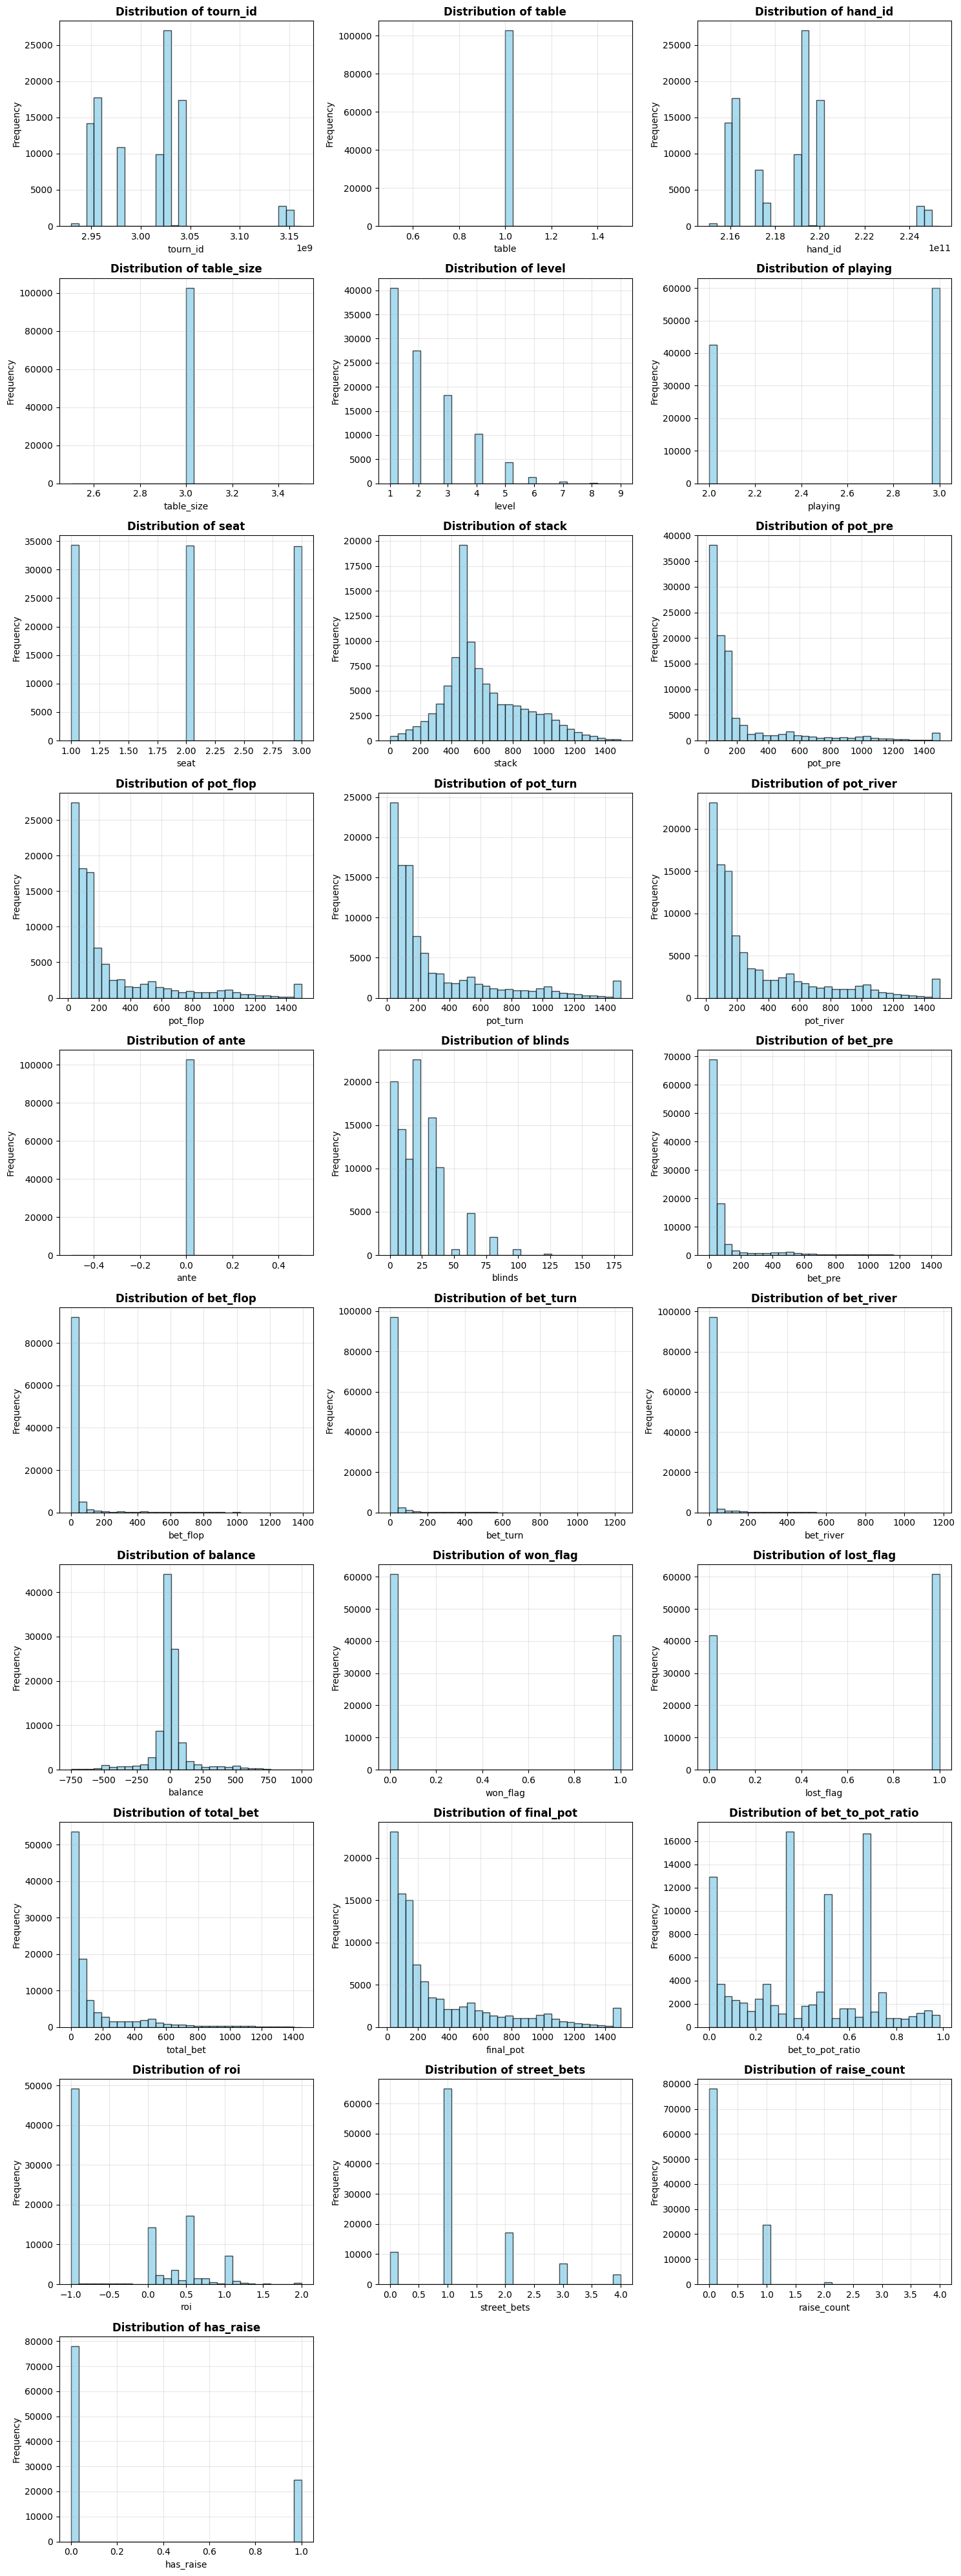

In [9]:
# Distribution Analysis - Numerical Columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
print(f"Numeric columns found: {list(numeric_cols)}")

# Create subplots for distributions
n_cols = len(numeric_cols)
if n_cols > 0:
    n_rows = (n_cols + 2) // 3
    fig, axes = plt.subplots(n_rows, 3, figsize=(15, n_rows * 4))
    axes = axes.flatten() if n_cols > 1 else [axes]
    
    for idx, col in enumerate(numeric_cols):
        axes[idx].hist(df[col].dropna(), bins=30, color='skyblue', edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'Distribution of {col}', fontweight='bold')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frequency')
        axes[idx].grid(alpha=0.3)
    
    # Hide unused subplots
    for idx in range(len(numeric_cols), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()


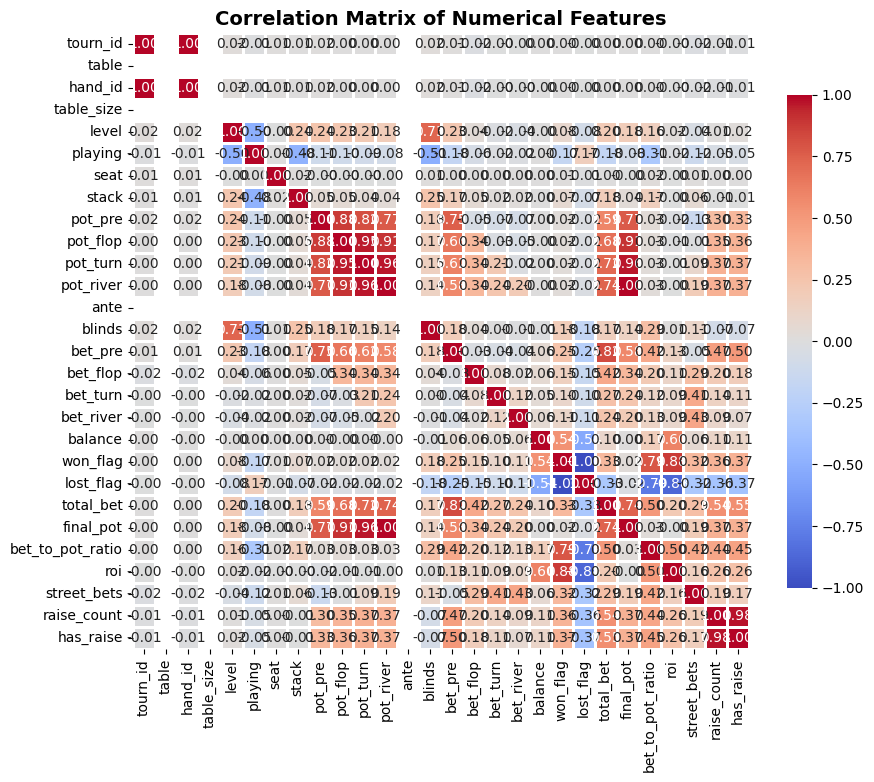

In [10]:
if len(numeric_cols) > 1:
    plt.figure(figsize=(10, 8))
    correlation_matrix = df[numeric_cols].corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
                fmt='.2f', square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title('Correlation Matrix of Numerical Features', fontsize=14, fontweight='bold')
    plt.show()
else:
    print("Not enough numeric columns for correlation analysis")


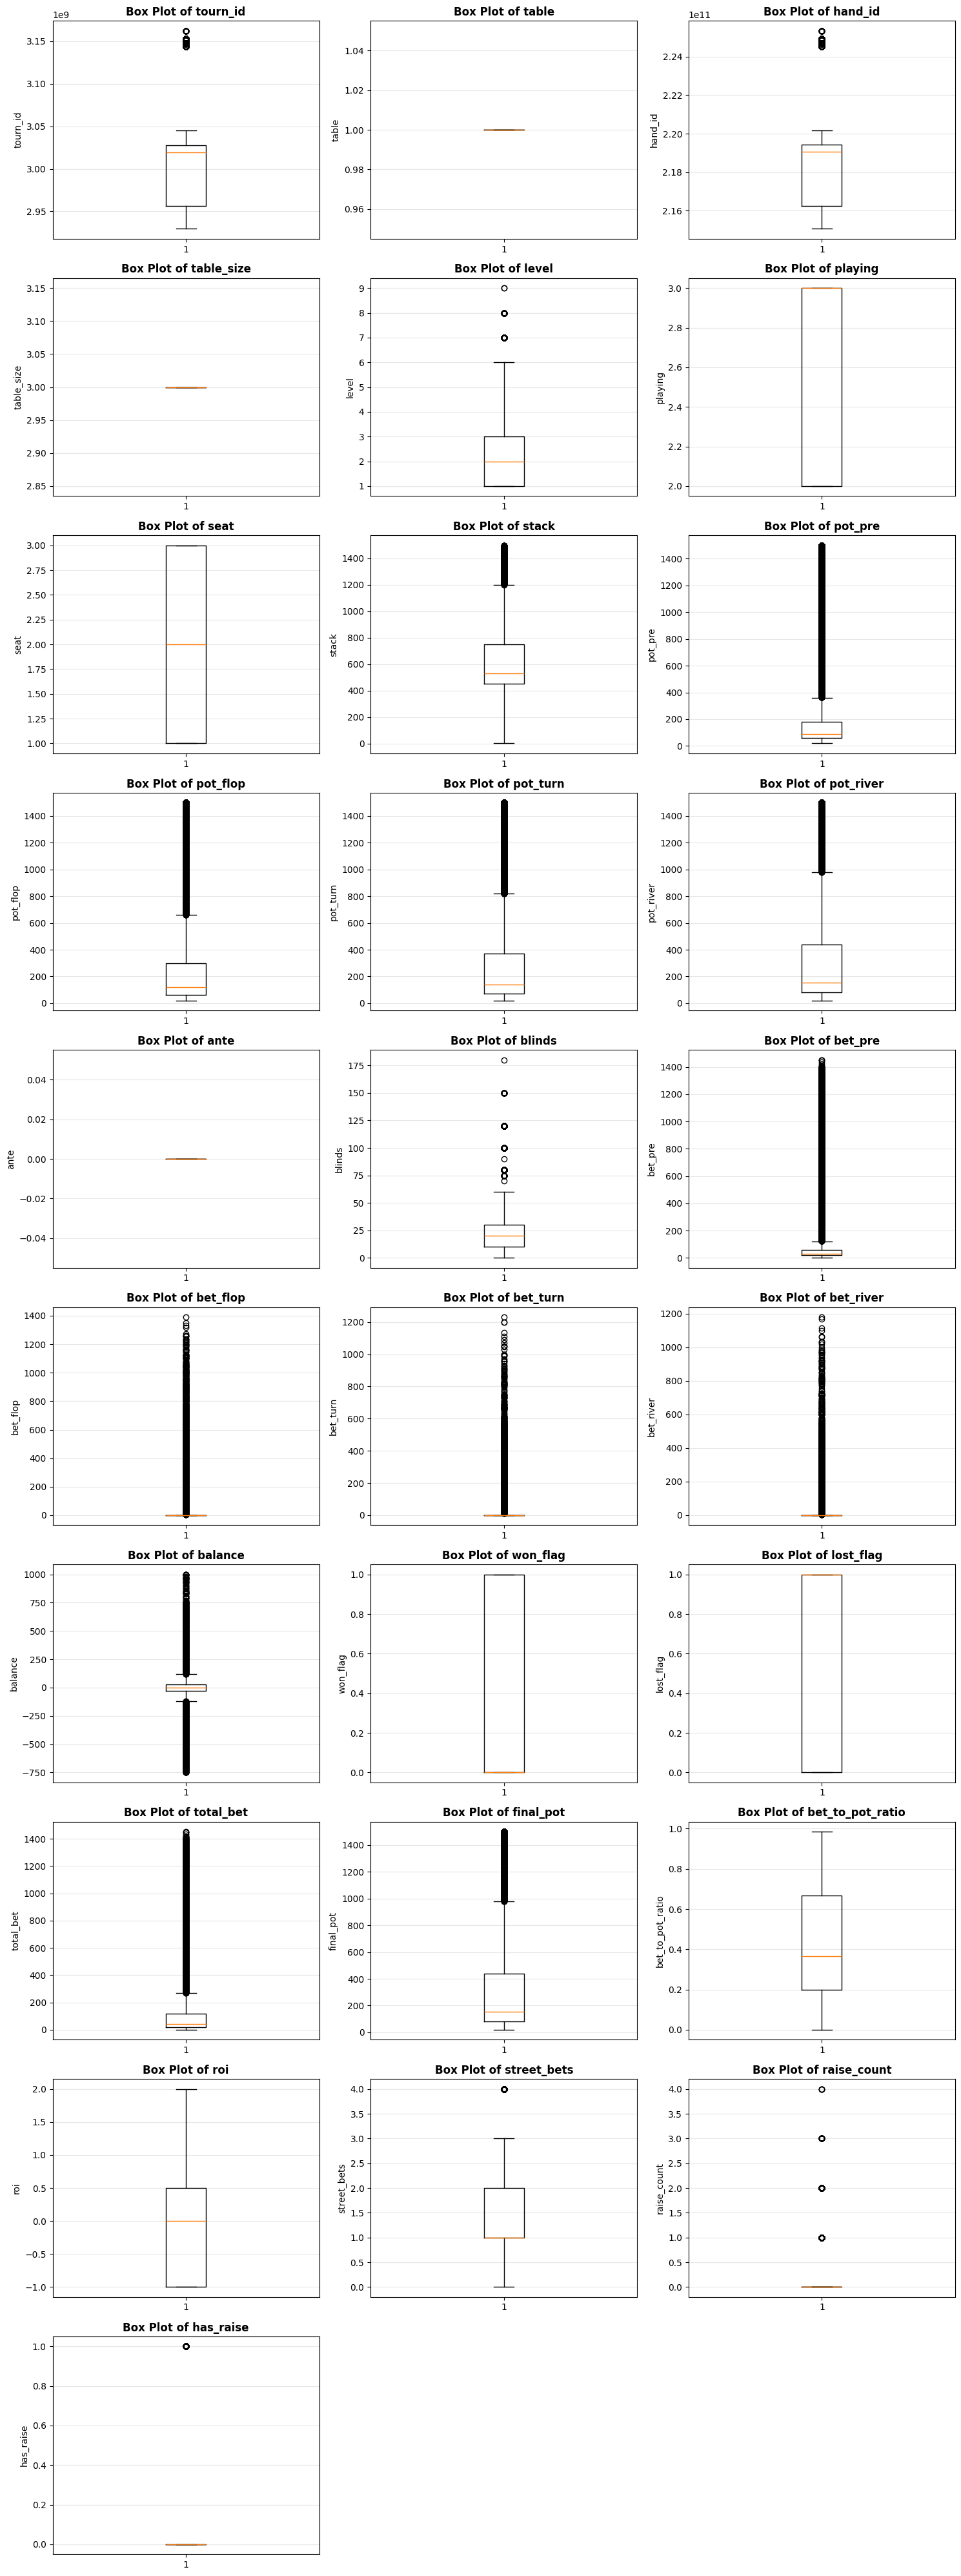

In [11]:
# Box Plots for Outlier Detection
if len(numeric_cols) > 0:
    n_rows = (len(numeric_cols) + 2) // 3
    fig, axes = plt.subplots(n_rows, 3, figsize=(15, n_rows * 4))
    axes = axes.flatten() if len(numeric_cols) > 1 else [axes]
    
    for idx, col in enumerate(numeric_cols):
        axes[idx].boxplot(df[col].dropna(), vert=True)
        axes[idx].set_title(f'Box Plot of {col}', fontweight='bold')
        axes[idx].set_ylabel(col)
        axes[idx].grid(alpha=0.3, axis='y')
    
    # Hide unused subplots
    for idx in range(len(numeric_cols), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()


C:\Users\garrido-lestachebeli\AppData\Local\Temp\ipykernel_32072\42568394.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


Categorical columns found: ['buyin', 'date', 'time', 'name', 'position', 'action_pre', 'action_flop', 'action_turn', 'action_river', 'cards', 'board_flop', 'board_turn', 'board_river', 'combination', 'result']


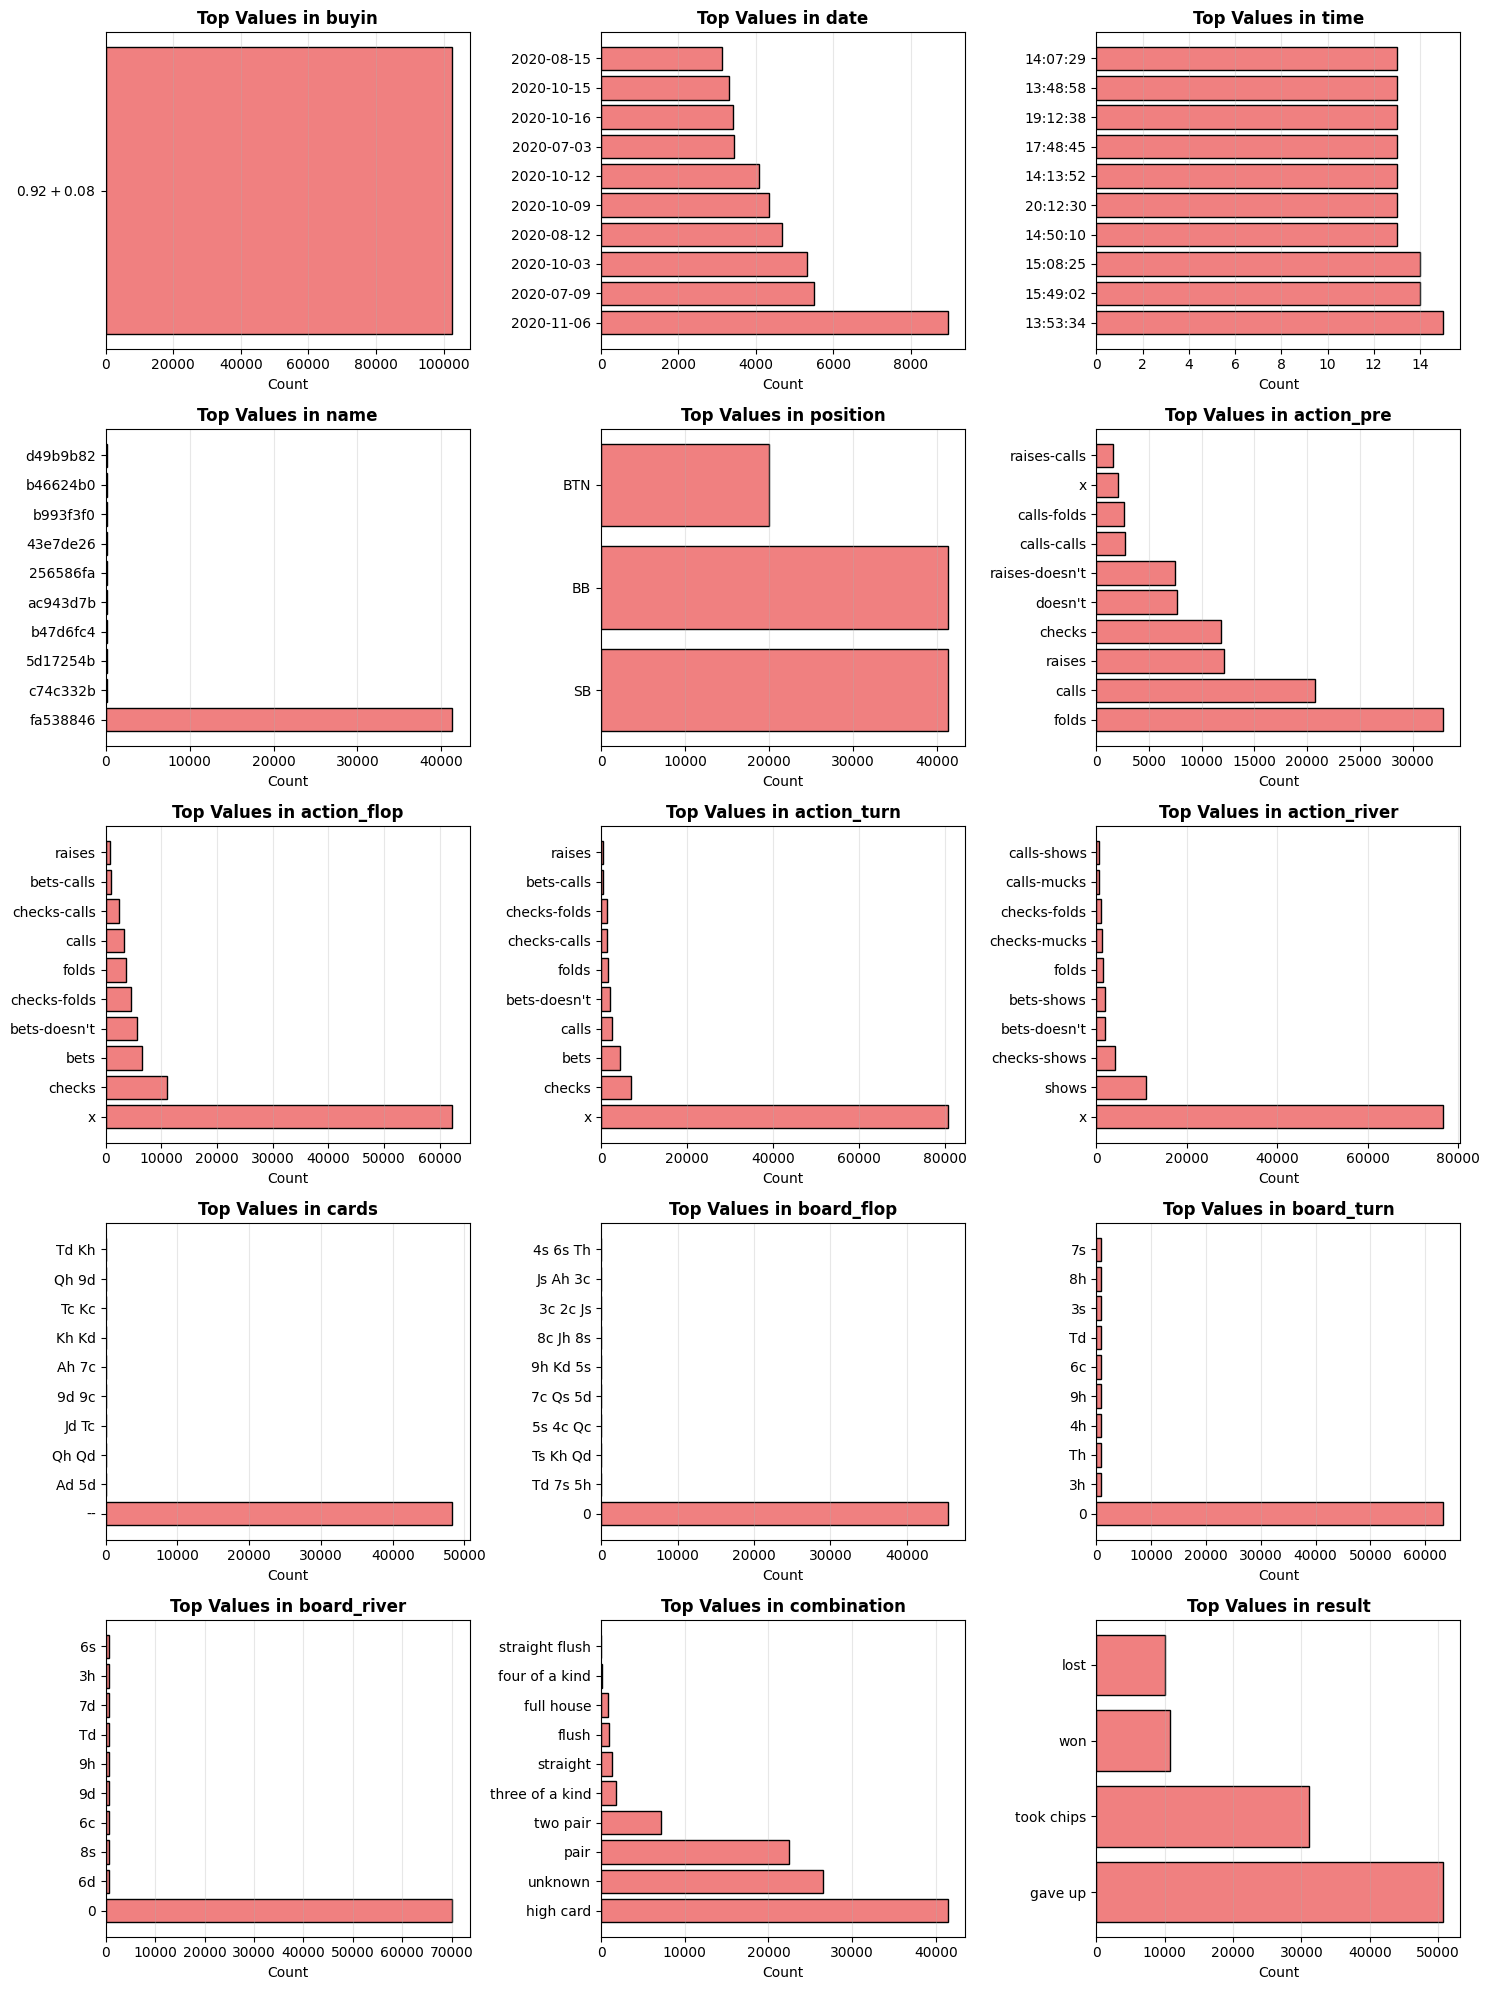

In [12]:

# Categorical Columns Analysis
categorical_cols = df.select_dtypes(include=['object']).columns
print(f"Categorical columns found: {list(categorical_cols)}")

if len(categorical_cols) > 0:
    n_rows = (len(categorical_cols) + 2) // 3
    fig, axes = plt.subplots(n_rows, 3, figsize=(15, n_rows * 4))
    axes = axes.flatten() if len(categorical_cols) > 1 else [axes]
    
    for idx, col in enumerate(categorical_cols):
        value_counts = df[col].value_counts().head(10)
        axes[idx].barh(range(len(value_counts)), value_counts.values, color='lightcoral', edgecolor='black')
        axes[idx].set_yticks(range(len(value_counts)))
        axes[idx].set_yticklabels(value_counts.index)
        axes[idx].set_title(f'Top Values in {col}', fontweight='bold')
        axes[idx].set_xlabel('Count')
        axes[idx].grid(alpha=0.3, axis='x')
    
    # Hide unused subplots
    for idx in range(len(categorical_cols), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()
else:
    print("No categorical columns found in the dataset")


## EDA Summary & Key Insights

### Dataset Overview
- **Shape**: Your dataset contains 100,000+ poker game records with 27 columns
- **Data Type**: Mix of numerical (19 columns) and categorical (15 columns) features

### Key Findings:

**1. Data Quality Issues**
- ⚠️ **85%+ Missing Values in 'combination' column** - May need to be dropped or filled with strategy
- Other columns appear to have good data completeness

**2. Numerical Features**
- **Highly Correlated Pot Amounts**: pot_pre, pot_flop, pot_turn, pot_river show strong correlations (0.8-0.96)
- **Stack Distribution**: Right-skewed with most stacks between 0-800 chips
- **Balance**: Shows both positive and negative values, indicating player wins and losses
- **Engineered features**: `total_bet`, `final_pot`, `bet_to_pot_ratio`, `roi`, `street_bets`, `raise_count`, `has_raise`, `won_flag`, and `lost_flag` are included in the numeric EDA

**3. Categorical Insights**
- **Positions**: Primarily 3 positions - SB (Small Blind), BB (Big Blind), BTN (Button)
- **Actions**: Common actions include folds, calls, raises, checks across pre-flop, flop, turn, river
- **Results**: Outcomes are "lost", "won", "took chips", and "gave up"
- **Dates**: Data from multiple dates in 2020

**4. Outliers Detected**
- Box plots reveal outliers in: stack sizes, betting amounts (bet_pre, bet_flop, bet_turn, bet_river)
- These may represent rare high-value hands or player behavior anomalies

### Next Steps for Analysis:
1. Decide on handling the 'combination' column with missing values
2. Analyze relationship between hand combinations and win/loss outcomes
3. Explore position-based strategy differences
4. Investigate player decision patterns across betting rounds


In [13]:
# T-test analysis for feature predictive power


# Define win/lose labels. 'won' and 'took chips' are treated as winning outcomes,
# while 'lost' and 'gave up' are treated as losing outcomes.
win_categories = ['won', 'took chips']
lose_categories = ['lost', 'gave up']

df['win_flag'] = df['result'].isin(win_categories)
df['lose_flag'] = df['result'].isin(lose_categories)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

win_group = df[df['win_flag']]
lose_group = df[df['lose_flag']]

win_vs_lose = []
for col in numeric_cols:
    if col in ['win_flag', 'lose_flag']:
        continue
    a = win_group[col].dropna()
    b = lose_group[col].dropna()
    if len(a) < 2 or len(b) < 2:
        continue
    t_stat, p_value = stats.ttest_ind(a, b, equal_var=False)
    win_vs_lose.append({
        'feature': col,
        'mean_win': a.mean(),
        'mean_lose': b.mean(),
        't_stat': t_stat,
        'p_value': p_value,
        'significant': p_value < 0.05,
        'n_win': len(a),
        'n_lose': len(b)
    })

win_vs_lose_df = pd.DataFrame(win_vs_lose).sort_values('p_value')
print('T-test: numeric feature differences for win vs lose groups')
print(win_vs_lose_df.to_string(index=False))

T-test: numeric feature differences for win vs lose groups
         feature     mean_win     mean_lose     t_stat       p_value  significant  n_win  n_lose
         playing 2.486132e+00  2.653071e+00 -53.608696  0.000000e+00         True  41859   60756
         balance 9.759808e+01 -6.724205e+01 197.107027  0.000000e+00         True  41859   60756
          blinds 2.582809e+01  1.882729e+01  57.339277  0.000000e+00         True  41859   60756
         bet_pre 1.405673e+02  5.082122e+01  74.279245  0.000000e+00         True  41859   60756
        bet_flop 3.782224e+01  1.172373e+01  44.128218  0.000000e+00         True  41859   60756
       total_bet 2.101719e+02  7.326508e+01 100.945148  0.000000e+00         True  41859   60756
       lost_flag 0.000000e+00  1.000000e+00       -inf  0.000000e+00         True  41859   60756
        won_flag 1.000000e+00  0.000000e+00        inf  0.000000e+00         True  41859   60756
       has_raise 4.297762e-01  1.088617e-01 117.562007  0.000000e+00

c:\Users\garrido-lestachebeli\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


In [14]:
positive = df[df['balance'] > 0]
negative = df[df['balance'] < 0]
amount_results = []
for col in numeric_cols:
    if col == 'balance':
        continue
    a = positive[col].dropna()
    b = negative[col].dropna()
    if len(a) < 2 or len(b) < 2:
        continue
    t_stat, p_value = stats.ttest_ind(a, b, equal_var=False)
    amount_results.append({
        'feature': col,
        'mean_positive': a.mean(),
        'mean_negative': b.mean(),
        't_stat': t_stat,
        'p_value': p_value,
        'significant': p_value < 0.05,
        'n_positive': len(a),
        'n_negative': len(b)
    })

amount_df = pd.DataFrame(amount_results).sort_values('p_value')
print('\nT-test: numeric feature differences for positive vs negative balance')
print(amount_df.to_string(index=False))


T-test: numeric feature differences for positive vs negative balance
         feature  mean_positive  mean_negative       t_stat       p_value  significant  n_positive  n_negative
        won_flag   1.000000e+00   9.575678e-04  7231.672170  0.000000e+00         True       41178       50127
         bet_pre   1.398440e+02   6.185188e+01    62.393714  0.000000e+00         True       41178       50127
     street_bets   1.618510e+00   1.283500e+00    65.396938  0.000000e+00         True       41178       50127
     raise_count   4.464763e-01   1.378898e-01   100.437458  0.000000e+00         True       41178       50127
             roi   5.773795e-01  -9.905744e-01   936.622028  0.000000e+00         True       41178       50127
bet_to_pot_ratio   6.532785e-01   2.810615e-01   384.224952  0.000000e+00         True       41178       50127
       total_bet   2.084256e+02   8.918986e+01    84.597683  0.000000e+00         True       41178       50127
       lost_flag   0.000000e+00   9.990424

c:\Users\garrido-lestachebeli\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


PCA explained variance:
  PC  Explained Variance Ratio  Cumulative Variance
 PC1                  0.343091             0.343091
 PC2                  0.169578             0.512669
 PC3                  0.103428             0.616097
 PC4                  0.079701             0.695799
 PC5                  0.076972             0.772770
 PC6                  0.070517             0.843287
 PC7                  0.067687             0.910974
 PC8                  0.032919             0.943893
 PC9                  0.027023             0.970916
PC10                  0.020622             0.991538


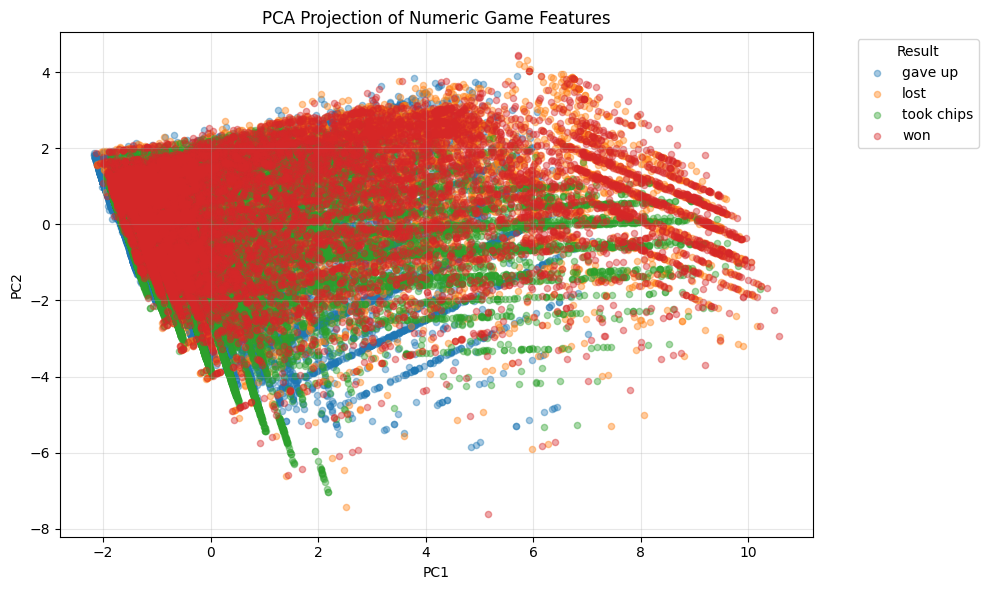

In [15]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Select numeric features from the EDA that are meaningful for PCA.
# Exclude identifiers, table info, and constant columns.
feature_cols = [
    'stack', 'blinds', 'bet_pre', 'bet_flop', 'bet_turn', 'bet_river',
    'pot_pre', 'pot_flop', 'pot_turn', 'pot_river',
    'level', 'playing', 'seat'
]

# Optionally include balance if you want PCA to reflect win/loss magnitude too.
# feature_cols.append('balance')

pca_df = df[feature_cols].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(pca_df)

pca = PCA(n_components=min(len(feature_cols), X_scaled.shape[0]))
components = pca.fit_transform(X_scaled)

explained = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(len(pca.explained_variance_ratio_))],
    'Explained Variance Ratio': pca.explained_variance_ratio_,
    'Cumulative Variance': np.cumsum(pca.explained_variance_ratio_)
})

print('PCA explained variance:')
print(explained.head(10).to_string(index=False))

# Create a PCA projection dataframe for the first two components
pca_projection = pd.DataFrame(components[:, :2], columns=['PC1', 'PC2'], index=pca_df.index)
if 'result' in df.columns:
    pca_projection['result'] = df.loc[pca_projection.index, 'result'].values

plt.figure(figsize=(10, 6))
for label, group in pca_projection.groupby('result'):
    plt.scatter(group['PC1'], group['PC2'], label=label, alpha=0.4, s=20)

plt.title('PCA Projection of Numeric Game Features')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Result', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Ensure binary win target is present.
df['win_flag'] = df['result'].isin(['won', 'took chips']).astype(int)

# Use only pre-outcome variables for prediction.
pre_outcome_numeric_features = [
    'stack', 'blinds', 'bet_pre', 'bet_flop', 'bet_turn', 'bet_river',
    'pot_pre', 'pot_flop', 'pot_turn', 'pot_river',
    'level', 'playing', 'seat',
    'total_bet', 'final_pot',
    'street_bets', 'raise_count', 'has_raise'
]

# Exclude outcome-derived features like ROI and balance from the predictors.
pre_outcome_categorical_features = ['position']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])


def fit_linear_model(target, target_name, numeric_features, categorical_features):
    preprocessor = ColumnTransformer(transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

    X = df[numeric_features + categorical_features].copy()
    y = target.copy()
    mask = X.notna().all(axis=1) & y.notna()
    X = X.loc[mask]
    y = y.loc[mask]

    model = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', LinearRegression())])
    model.fit(X, y)

    ohe = model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
    cat_names = ohe.get_feature_names_out(categorical_features).tolist()
    feature_names = numeric_features + cat_names

    coefs = model.named_steps['regressor'].coef_
    coef_df = pd.DataFrame({
        'feature': feature_names,
        'coefficient': coefs
    })
    coef_df['abs_coef'] = coef_df['coefficient'].abs()
    coef_df = coef_df.sort_values('abs_coef', ascending=False)

    print(f"--- {target_name} Linear Regression ---")
    print(f"Samples used: {len(y)}")
    print(coef_df.head(15).to_string(index=False))
    print()
    return coef_df

win_coef = fit_linear_model(
    df['win_flag'],
    'Win Flag',
    pre_outcome_numeric_features,
    pre_outcome_categorical_features
)
balance_coef = fit_linear_model(
    df['balance'],
    'Balance (Win Amount)',
    pre_outcome_numeric_features,
    pre_outcome_categorical_features
)

print('Top predictors for winning:')
print(win_coef.head(10)[['feature', 'coefficient']].to_string(index=False))

--- Win Flag Linear Regression ---
Samples used: 102615
    feature  coefficient  abs_coef
  final_pot    -0.184893  0.184893
  pot_river    -0.184893  0.184893
  has_raise     0.170916  0.170916
street_bets     0.138157  0.138157
  total_bet     0.104206  0.104206
position_SB    -0.086515  0.086515
    pot_pre     0.076514  0.076514
    bet_pre     0.074776  0.074776
   pot_turn     0.072271  0.072271
position_BB     0.068765  0.068765
   bet_flop     0.061854  0.061854
     blinds     0.039006  0.039006
  bet_river     0.038697  0.038697
raise_count    -0.035629  0.035629
    playing    -0.032521  0.032521

--- Balance (Win Amount) Linear Regression ---
Samples used: 102615
     feature  coefficient  abs_coef
   final_pot   -33.498113 33.498113
   pot_river   -33.498113 33.498113
 raise_count    20.051172 20.051172
    pot_turn    18.848273 18.848273
     pot_pre    17.362156 17.362156
   bet_river    16.623965 16.623965
   total_bet    14.326269 14.326269
    bet_flop    12.123590 1

In [ ]:
# Analyze why bet_to_pot_ratio is so important
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation with win_flag
correlation = df[['bet_to_pot_ratio', 'won_flag']].corr()
print("Correlation between bet_to_pot_ratio and won_flag:")
print(correlation)

# Distribution by win/loss
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='bet_to_pot_ratio', hue='won_flag', bins=50, alpha=0.7)
plt.title('Bet to Pot Ratio Distribution by Win/Loss')
plt.xlabel('Bet to Pot Ratio')
plt.ylabel('Count')
plt.show()

# Average bet_to_pot_ratio for winners vs losers
avg_ratio = df.groupby('won_flag')['bet_to_pot_ratio'].mean()
print("\nAverage bet_to_pot_ratio:")
print(f"Losers: {avg_ratio[0]:.3f}")
print(f"Winners: {avg_ratio[1]:.3f}")


Top predictors for balance:


NameError: name 'balance_coef' is not defined

In [36]:
import joblib
models = joblib.load('poker_models.pkl')

# For a game state, extract features for current stage
stage = 'river'  # current betting round
features = {
    'hand_strength': 9,  # e.g., three of a kind
    'total_bet': 3000,
    'current_pot': 300,
    'bet_to_pot_ratio': 0.2,
    'raise_count': 1,
    'has_raise': 1,
    'street_bets': 2
}

# Get win probability
model = models[stage]
prob_win = model.predict_proba([list(features.values())])[0][1]
print(f"Win probability: {prob_win:.2%}")

Win probability: 58.39%


c:\Users\garrido-lestachebeli\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\garrido-lestachebeli\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\garrido-lestachebeli\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
